Adapted from [Shashank Kapadia](https://github.com/kapadias/medium-articles/blob/master/natural-language-processing/topic-modeling/Evaluate%20Topic%20Models.ipynb)

In [1]:
import os
import logging
from collections import Counter
from pathlib import Path
from pprint import pformat

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import gensim
from gensim.corpora import Dictionary
from gensim.models import Phrases, phrases, LdaMulticore, CoherenceModel
from gensim.utils import simple_preprocess, ClippedCorpus

import nltk
import spacy
from nltk.corpus import stopwords

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

from tqdm import tqdm

In [4]:
# Download once
# nltk.download('stopwords', quiet=True)

True

In [5]:
# Download once
# !python -m spacy download en_core_web_sm

/Users/asa/miniforge3/envs/wp2_paper/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=41996) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 40.0 MB/s  0:00:00.6 MB/s eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [28]:
def setup_logging(INTERMEDIATE_PATH, PHASE):
    """
    Set up logging configuration.
    
    Args:
        INTERMEDIATE_PATH (str): Directory to store log files.
        PHASE (str): Phase of analysis ("prompt_opt", "final_pred", or "experimental").
        
    Returns:
        Configured logger instance.
    """
    log_dir = INTERMEDIATE_PATH / PHASE
    log_dir.mkdir(parents=True, exist_ok=True)
    
    log_file = log_dir / "3_2.log"
    
    logging.basicConfig(
        level=logging.DEBUG,
        format='%(asctime)s - %(levelname)s - %(message)s',
        handlers=[
            logging.FileHandler(log_file),
            logging.StreamHandler()
        ]
    )
    return logging.getLogger(__name__)

def load_clean_tokenize(OUTPUT_DIR, PHASE, TYPOLOGY, TYPOLOGY_TYPE=None):
    """
    Load, clean, and tokenize text data from Excel files.

    Args:
        OUTPUT_DIR (str): The directory where the output is stored.
        PHASE (str): Phase of analysis ("prompt_opt", "final_pred", or "experimental").
        TYPOLOGY (str): The typology to filter by.
        TYPOLOGY_TYPE (str, optional): The specific type of typology to filter by (Default: None).

    Returns:
        A list of tokenized sentences.
    """
    typology_prediction_result_dir = OUTPUT_DIR.parent.parent / "3_1" / PHASE
    excel_paths = list(typology_prediction_result_dir.glob("*.xlsx"))
    
    if not excel_paths:
        logging.warning(f"No Excel files found in {typology_prediction_result_dir}")

    all_cleaned = []

    for path in excel_paths:
        df = pd.read_excel(path)
        
        if TYPOLOGY_TYPE is not None:
            logging.debug(f"Filtering by typology type: {TYPOLOGY_TYPE}")
            df = df[df[ TYPOLOGY].str.lower() == TYPOLOGY_TYPE.lower()]

        try:
            col = "reason_" + TYPOLOGY
            cleaned = df[col].astype(str).str.replace(r'[,\.!?]', '', regex=True).str.lower()
        except:
            col = TYPOLOGY + "_reason"
            cleaned = df[col].astype(str).str.replace(r'[,\.!?]', '', regex=True).str.lower()

        all_cleaned.extend(cleaned)

    logging.debug(f"Total cleaned sentences: {len(all_cleaned)}")
    tokenized_sentences = [simple_preprocess(str(s), deacc=True) for s in all_cleaned]
    
    return tokenized_sentences

def data_preprocessing(data_words, additional_stopwords):
    """
    Preprocess the input text data by removing stopwords, creating bigrams and trigrams,
    lemmatizing, and building a dictionary and corpus.

    Args:
        data_words (List[List[str]]): The input text data as a list of tokenized words.
        additional_stopwords (List[str]): Additional stopwords to remove.

    Returns:
        List[List[str]]: The lemmatized text data.
        Dictionary: The dictionary of the corpus.
        List[Tuple[int, int]]: The corpus in BoW format.
    """
    # Build phrase models
    bigram = Phrases(data_words, min_count=5, threshold=10)
    trigram = Phrases(bigram[data_words], threshold=10)
    
    bigram_mod = phrases.Phraser(bigram)
    trigram_mod = phrases.Phraser(trigram)
    
    # Preprocessing pipeline
    # Extended stopwords for iterations
    stop_words = set(stopwords.words('english')).union(additional_stopwords)
    data_nostop = [[word for word in doc if word not in stop_words] for doc in data_words]
    
    logging.debug(f"Data after removing stopwords: {data_nostop[:5]}")
    
    data_bigram = [bigram_mod[doc] for doc in data_nostop]
    logging.debug(f"Data after creating bigrams: {data_bigram[:5]}")
    
    # Load spaCy model once
    nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])
    
    # Lemmatize (only nouns)
    allowed_postags = ['NOUN']  # Select ['NOUN'] to get what our models "see" and use as their rationales for predictions
    data_lemmatized = [
        [token.lemma_ for token in nlp(" ".join(doc)) if token.pos_ in allowed_postags]
        for doc in data_bigram
    ]

    logging.debug(f"Lemmatized data: {data_lemmatized[:5]}")
    
    # Create dictionary and corpus
    id2word = Dictionary(data_lemmatized)
    logging.debug(f"Dictionary created with {len(id2word)} unique words.")
    
    corpus = [id2word.doc2bow(text) for text in data_lemmatized]
    logging.debug(f"Corpus created with {len(corpus)} documents.")
    
    return data_lemmatized, id2word, corpus

def lda_base_model(RANDOM_STATE, CHUNKSIZE, PASSES, WORKERS, corpus, data_lemmatized, id2word):
    """
    Build and evaluate a baseline LDA model using the provided corpus and dictionary.

    Args:
        RANDOM_STATE (int): The random state for reproducibility.
        CHUNKSIZE (int): Size of the chunk for processing.
        PASSES (int): Number of passes through the corpus during training.
        WORKERS (int): Number of worker processes to use for parallelization.
        corpus (List[Tuple[int, int]]): The corpus in BoW format.
        data_lemmatized (List[List[str]]): The lemmatized text data.
        id2word (gensim.corpora.Dictionary): The dictionary of the corpus.

    Returns:
        A trained baseline LDA model.
    """
    
    # Build baseline LDA model
    lda_model = LdaMulticore(
        corpus=corpus,
        id2word=id2word,
        num_topics=10,
        random_state=RANDOM_STATE,
        chunksize=CHUNKSIZE,
        passes=PASSES,
        per_word_topics=True,
        workers=WORKERS
    )
    
    # Show topics
    topics = lda_model.print_topics()
    logging.debug(f"Topics: {pformat(topics)}")
    
    # Evaluate model
    coherence = CoherenceModel(model=lda_model, texts=data_lemmatized, dictionary=id2word, coherence='c_v').get_coherence()
    logging.info(f'Coherence Score: {coherence:.4f}')
    
    # Visualize topics
    try:
        pyLDAvis.enable_notebook()
        vis = gensimvis.prepare(lda_model, corpus, id2word)
    except Exception as e:
        logging.error(f"Error visualizing topics: {e}")
    
    return lda_model, pyLDAvis.display(vis)

def compute_coherence(RANDOM_STATE, CHUNKSIZE, PASSES, WORKERS, corpus, id2word, alpha, beta, num_topics, data_lemmatized):
    """
    Compute the coherence score for an LDA model with specified parameters.

    Args:
        RANDOM_STATE (int): The random state for reproducibility.
        CHUNKSIZE (int): Size of the chunk for processing.
        PASSES (int): Number of passes through the corpus during training.
        WORKERS (int): Number of worker processes to use for parallelization.
        corpus (List[Tuple[int, int]]): The corpus in BoW format.
        id2word (gensim.corpora.Dictionary): The dictionary of the corpus.
        alpha (float): Hyperparameter for document-topic distribution.
        beta (float): Hyperparameter for topic-word distribution.
        num_topics (int): Number of topics to infer.
        data_lemmatized (List[List[str]]): The lemmatized text data.

    Returns:
        The coherence score of the model.
    """
    # Build LDA model
    model = LdaMulticore(
        corpus=corpus,
        id2word=id2word,
        num_topics=num_topics,
        random_state=RANDOM_STATE,
        chunksize=CHUNKSIZE,
        passes=PASSES,
        alpha=alpha,
        eta=beta,
        workers=WORKERS
    )
    
    # Compute coherence score
    coherence_model = CoherenceModel(model=model, texts=data_lemmatized, dictionary=id2word, coherence='c_v')
    coherence_score = coherence_model.get_coherence()
    
    logging.debug(f"Coherence Score for {num_topics} topics: {coherence_score:.4f}")
    
    return coherence_score

def tune_lda(TYPOLOGY, OUTPUT_DIR, RANDOM_STATE, CHUNKSIZE, PASSES, WORKERS, corpus, id2word, data_lemmatized, TYPOLOGY_TYPE=None):
    """
    Perform grid search to find the best parameters for LDA model.

    Args:
        TYPOLOGY (str): The type of topology.
        OUTPUT_DIR (Path): Directory to save the results.
        RANDOM_STATE (int): The random state for reproducibility.
        CHUNKSIZE (int): Size of the chunk for processing.
        PASSES (int): Number of passes through the corpus during training.
        WORKERS (int): Number of worker processes to use for parallelization.
        corpus (List[Tuple[int, int]]): The corpus in BoW format.
        id2word (gensim.corpora.Dictionary): The dictionary of the corpus.
        TYPOLOGY_TYPE (str, optional): The specific type of typology to filter by (Default: None).

    Returns:
        pd.DataFrame: DataFrame containing the results of the grid search.
        dict: Best hyperparameters found.
    """
    # Parameter Grid
    topics_range = range(4, 7, 2)
    alphas = list(np.arange(0.01, 1, 0.3)) + ['symmetric', 'asymmetric']
    betas = list(np.arange(0.01, 1, 0.3)) + ['symmetric', 'auto']

    # Corpus sets
    corpus_sets = [ClippedCorpus(corpus, int(len(corpus)*0.75)), corpus]
    titles = ['75% Corpus', '100% Corpus']
    
    # Run Grid Search
    results = []
    pbar = tqdm(total=len(topics_range) * len(alphas) * len(betas) * len(corpus_sets))
    
    for corpus_set, title in zip(corpus_sets, titles):
        for num_topics in topics_range:
            for alpha in alphas:
                for beta in betas:
                    coherence = compute_coherence(RANDOM_STATE, CHUNKSIZE, PASSES, WORKERS, corpus, id2word, alpha, beta, num_topics, data_lemmatized)
                    results.append({
                        "Validation_Set": title, "Topics": num_topics,
                        "Alpha": alpha, "Beta": beta, "Coherence": coherence
                    })
                    pbar.update(1)
    pbar.close()
    
    df = pd.DataFrame(results)

    # Save tuning parameters
    if TYPOLOGY_TYPE is not None:
        tune_path = OUTPUT_DIR / f"lda_{TYPOLOGY}_{TYPOLOGY_TYPE}_tuning_results.csv"
    tune_path = OUTPUT_DIR / f"lda_{TYPOLOGY}_tuning_results.csv"
    
    df.to_csv(tune_path, index=False)
    
    # Analyze Results
    df_plot = df[["Topics", "Alpha", "Beta", "Coherence"]].sort_values("Coherence", ascending=False)

    # Best Params
    best = df_plot.iloc[df_plot.Coherence.argmax()]

    logging.info(f"Optimum Coherence: {best['Coherence']:.2f}")
    logging.info(f"Best #Topics: {best['Topics']}, Alpha: {best['Alpha']}, Beta: {best['Beta']}")
    logging.info(f"Improvement over base: {((best.Coherence - coherence) / coherence)*100:.2f}% ({best.Coherence - coherence:.2f} points)")

    return df_plot, best

def plot_lda_tuning_result(df_plot):
    """
    Plots the results of LDA tuning by creating histograms and scatter plots for coherence scores
    across different numbers of topics, alpha values, and beta values.
    
    Args:
        df_plot (DataFrame): A DataFrame containing columns 'Topics', 'Coherence', 'Alpha', and 'Beta'.

    Returns:
        Plots of LDA hyperparameter tuning results.
    """
    plt.style.use('fivethirtyeight')
    
    # Plot histogram of coherence scores
    logging.debug("Plotting Coherence Score Distribution")
    df_plot['Coherence'].plot(kind='hist', title='Coherence Score Distribution')
    plt.show()
    
    # Plot scatter plot of topics vs coherence
    logging.debug("Plotting Topics vs Coherence")
    df_plot.plot.scatter(x='Topics', y='Coherence', title='Topics vs Coherence')
    plt.show()
    
    # Plot scatter plot of alpha vs coherence
    logging.debug("Converting Alpha values to string for plotting")
    df_plot['Alpha'] = df_plot['Alpha'].astype(str)
    logging.debug("Plotting Alpha vs Coherence")
    ax = df_plot.plot.scatter(x='Alpha', y='Coherence', title='Alpha vs Coherence')
    plt.xticks(rotation=45)
    plt.show()
    
    # Plot scatter plot of beta vs coherence
    logging.debug("Converting Beta values to string for plotting")
    df_plot['Beta'] = df_plot['Beta'].astype(str)
    logging.debug("Plotting Beta vs Coherence")
    df_plot.plot.scatter(x='Beta', y='Coherence', title='Beta vs Coherence')
    plt.xticks(rotation=45)
    plt.show()

def lda_tuned_model(RANDOM_STATE, CHUNKSIZE, PASSES, WORKERS, corpus, id2word, best):
    """
    Trains a final LDA model using the best hyperparameters obtained from tuning and visualizes the topics.

    Args:
        RANDOM_STATE (int): The random state for reproducibility.
        CHUNKSIZE (int): Size of the chunk for processing.
        PASSES (int): Number of passes through the corpus during training.
        WORKERS (int): Number of worker processes to use for parallelization.
        corpus (List[Tuple[int, int]]): The corpus in BoW format.
        id2word (gensim.corpora.Dictionary): The dictionary of the corpus.
        best (DataFrame): A DataFrame containing parameters which yielded highest coherence score.
    
    Returns:
        The trained tuned LDA model.
    """
    # Convert alpha and beta to float if possible
    best_alpha = best.Alpha
    best_beta = best.Beta
    for var in ["best_alpha", "best_beta"]:
        try:
            # Try converting the variable to float
            locals()[var] = float(locals()[var])
        except (ValueError, TypeError):
            # If it can't be converted, leave it as is
            logging.warning(f"Failed to convert {var} to float. Using original value.")
            pass
    
    # Train final LDA model with tuned hyperparameters
    logging.debug("Training LDA model with tuned hyperparameters")
    lda_model = gensim.models.LdaMulticore(
        corpus=corpus,
        id2word=id2word,
        num_topics=best.Topics,
        random_state=RANDOM_STATE,
        chunksize=CHUNKSIZE,
        passes=PASSES,
        alpha=best_alpha,
        eta=best_beta,
        workers=WORKERS
    )
    
    # Display top keywords per topic
    logging.debug("Extracting top keywords per topic")
    topic_summaries = {}
    for topic_id in range(lda_model.num_topics):
        top_words = [word for word, _ in lda_model.show_topic(topic_id, topn=10)]
        topic_summaries[topic_id] = ", ".join(top_words)
    
    # Log summaries
    for tid, summary in topic_summaries.items():
        logging.info(f"Topic {tid}: {summary}")
    
    # Inference and save model
    logging.debug("Performing inference on the corpus")
    doc_lda = lda_model[corpus]

    # Determine model save path
    if TYPOLOGY_TYPE is not None:
        model_path = "./" + str(OUTPUT_DIR) + f"lda_{TYPOLOGY}_{TYPOLOGY_TYPE}.model"
    model_path = "./" + str(OUTPUT_DIR) + f"lda_{TYPOLOGY}.model"

    logging.debug(f"Saving model to {model_path}")
    lda_model.save(model_path)
    
    # Visualize topics and save HTML
    logging.debug("Enabling notebook for visualization")
    pyLDAvis.enable_notebook()

    logging.debug("Preparing LDA model for visualization")
    vis = gensimvis.prepare(lda_model, corpus, id2word)

    # Determine visualization save path
    if TYPOLOGY_TYPE is not None:
        model_viz_path = "./" + str(OUTPUT_DIR) + f"viz_{TYPOLOGY}_{TYPOLOGY_TYPE}.html"
    model_viz_path = "./" + str(OUTPUT_DIR) + f"viz_{TYPOLOGY}.html"

    logging.debug(f"Saving visualization to {model_viz_path}")
    pyLDAvis.save_html(vis, model_viz_path)
    
    logging.debug("Displaying visualization")

    return lda_model, vis

def get_top_10_frequency_and_probability(lda_model):
    """
    Computes and plots the top 10 word frequencies and probabilities for each topic in an LDA model.
    
    Args:
        lda_model (LdaMulticore): The trained LDA model.

    Returns:
        Saved top 10 word frequencies and probabilities for each topics.
    """
    def plot_bar(words, values, title, path, color):
        """
        Plots a horizontal bar chart with the given words and values.
        
        Args:
            words (list): List of words to plot.
            values (list): Corresponding values for each word.
            title (str): Title of the plot.
            path (Path): Path where the plot will be saved.
            color (str): Color of the bars in the plot.
        
        Returns:
            Plot of a horizontal bar chart with the given words and values.
        """
        plt.figure(figsize=(10, 5))
        plt.barh(words, values, color=color)
        plt.ylabel("Words")
        plt.xlabel("Frequency" if "Frequency" in title else "Probability")
        plt.title(title)
        plt.gca().invert_yaxis()
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.savefig(path, dpi=300, bbox_inches='tight')
        plt.close()
    
    NUM_WORDS = 10
    
    freq_path = OUTPUT_DIR / "plots_top_10_word_freq"
    prob_path = OUTPUT_DIR / "plots_top_10_word_prob"
    
    logging.debug(f"Creating directories for plots: {freq_path} and {prob_path}")
    freq_path.mkdir(parents=True, exist_ok=True)
    prob_path.mkdir(parents=True, exist_ok=True)
    
    # Compute weighted word frequencies per topic
    logging.debug("Computing weighted word frequencies per topic")
    topic_word_freq = {i: Counter() for i in range(lda_model.num_topics)}
    for doc in corpus:
        topic_dist = lda_model.get_document_topics(doc, minimum_probability=0.0)
        for word_id, freq in doc:
            word = id2word[word_id]
            for topic_id, prob in topic_dist:
                topic_word_freq[topic_id][word] += freq * prob
    
    # Plot weighted word frequency per topic
    for topic_id, word_counter in topic_word_freq.items():
        top_words = word_counter.most_common(NUM_WORDS)
        if top_words:
            words, freqs = zip(*top_words)
            title = f"construction - Topic {topic_id} - Top Word Frequencies"
            path = freq_path / f"construction_{topic_id}.png"

            logging.debug(f"Saving {title} plot at {path}")
            plot_bar(words, freqs,
                     title=title,
                     path=path,
                     color='skyblue')
    
    # Plot top words by probability per topic
    for topic_id in range(lda_model.num_topics):
        top_words = lda_model.show_topic(topic_id, topn=NUM_WORDS)
        if top_words:
            words, probs = zip(*top_words)
            title = f"construction - Topic {topic_id} - Top Word Probabilities"
            path = prob_path / f"construction_{topic_id}.png"
            
            logging.debug(f"Saving {title} plot at {path}")
            plot_bar(words, probs,
                     title=title,
                     path=path,
                     color='lightcoral')

In [3]:
# Configuration
PHASE = "prompt_opt" # "prompt_opt", "final_pred", or "experimental"
INTERMEDIATE_DIR = Path("./temp/3_2")
OUTPUT_DIR = Path(f"./output/3_2/{PHASE}")

# Create directories if they don't exist
INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Preprocessing parameters
TYPOLOGY = "construction"
TYPOLOGY_TYPE = None

# LDA parameters
RANDOM_STATE = 100  # Adjustable
CHUNKSIZE = 100  # Adjustable
PASSES = 1  # Adjustable
WORKERS = 10  # Adjust according to the amount of your device's CPU

logger = setup_logging(INTERMEDIATE_DIR, PHASE)
logging.getLogger('gensim').setLevel(logging.ERROR)
plt.set_loglevel("error")

In [4]:
additional_stopwords = {
    "construction", "constructions", "building", "buildings"
}  # Example

data_words = load_clean_tokenize(OUTPUT_DIR, PHASE, TYPOLOGY, TYPOLOGY_TYPE=TYPOLOGY_TYPE)
data_lemmatized, id2word, corpus = data_preprocessing(data_words, additional_stopwords)

2025-10-27 16:39:26,860 - DEBUG - Total cleaned sentences: 24000
2025-10-27 16:39:30,205 - DEBUG - Data after removing stopwords: [['modern', 'north', 'jakarta', 'residential', 'shows', 'typical', 'reinforced', 'concrete', 'evident', 'white', 'painted', 'structural', 'walls', 'multi', 'story', 'design', 'cantilevered', 'balconies', 'characteristic', 'flat', 'roof', 'solar', 'panels', 'robust', 'foundation', 'load', 'bearing', 'capacity', 'needed', 'jakarta', 'soil', 'conditions', 'also', 'suggests', 'reinforced', 'concrete'], ['shows', 'typical', 'industrial', 'warehouse', 'metal', 'cladding', 'panels', 'roller', 'shutter', 'doors', 'steel', 'frame', 'structure', 'visible', 'upper', 'floors', 'corrugated', 'metal', 'walls', 'roofing', 'common', 'commercial', 'north', 'jakarta', 'industrial', 'areas', 'optimized', 'cost', 'durability', 'tropical', 'climate'], ['shows', 'typical', 'characteristics', 'north', 'jakarta', 'small', 'commercial', 'structure', 'concrete', 'foundations', 'posts

In [5]:
lda_model_base, vis = lda_base_model(RANDOM_STATE, CHUNKSIZE, PASSES, WORKERS, corpus, data_lemmatized, id2word)
vis

2025-10-27 16:40:25,014 - DEBUG - Topics: [(0,
  '0.104*"wall" + 0.095*"structure" + 0.055*"frame" + 0.044*"characteristic" + '
  '0.041*"area" + 0.037*"durability" + 0.037*"concrete" + 0.032*"surface" + '
  '0.031*"withstand" + 0.024*"multi_story"'),
 (1,
  '0.093*"wall" + 0.092*"column" + 0.084*"frame" + 0.073*"structure" + '
  '0.053*"element" + 0.052*"beam" + 0.036*"characteristic" + 0.028*"area" + '
  '0.028*"concrete" + 0.026*"material"'),
 (2,
  '0.069*"wall" + 0.066*"structure" + 0.063*"feature" + 0.059*"design" + '
  '0.053*"display" + 0.052*"facade" + 0.048*"material" + 0.045*"area" + '
  '0.041*"column" + 0.039*"concrete"'),
 (3,
  '0.110*"metal" + 0.084*"structure" + 0.078*"wall" + 0.057*"material" + '
  '0.042*"steel" + 0.037*"element" + 0.036*"concrete" + 0.036*"area" + '
  '0.035*"use" + 0.035*"frame"'),
 (4,
  '0.083*"durability" + 0.078*"material" + 0.069*"wall" + 0.056*"element" + '
  '0.045*"structure" + 0.039*"surface" + 0.033*"area" + 0.031*"characteristic" '
  '+ 

100%|█████████████████████████████████████████████████████| 144/144 [08:18<00:00,  3.46s/it]
2025-10-27 16:48:50,668 - INFO - Optimum Coherence: 0.28
2025-10-27 16:48:50,668 - INFO - Best #Topics: 4, Alpha: asymmetric, Beta: 0.61
2025-10-27 16:48:50,668 - INFO - Improvement over base: 18.41% (0.04 points)
2025-10-27 16:48:50,670 - DEBUG - Plotting Coherence Score Distribution


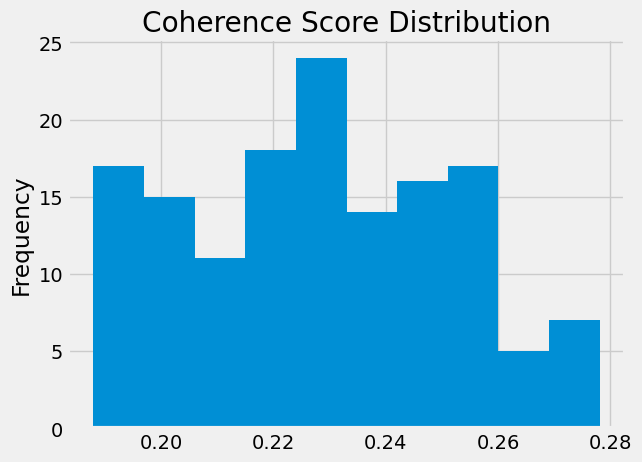

2025-10-27 16:48:50,930 - DEBUG - Plotting Topics vs Coherence


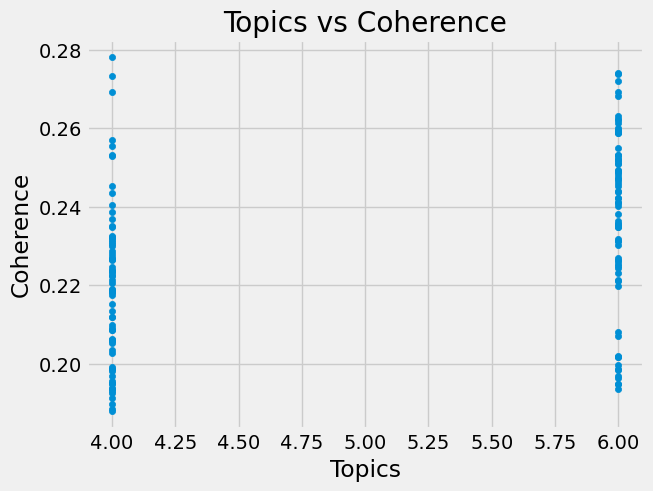

2025-10-27 16:48:50,996 - DEBUG - Converting Alpha values to string for plotting
2025-10-27 16:48:50,997 - DEBUG - Plotting Alpha vs Coherence


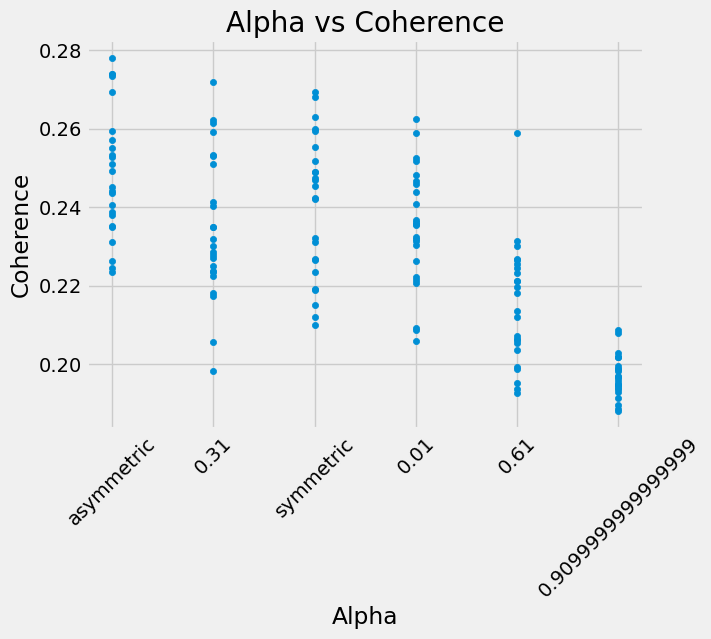

2025-10-27 16:48:51,064 - DEBUG - Converting Beta values to string for plotting
2025-10-27 16:48:51,064 - DEBUG - Plotting Beta vs Coherence


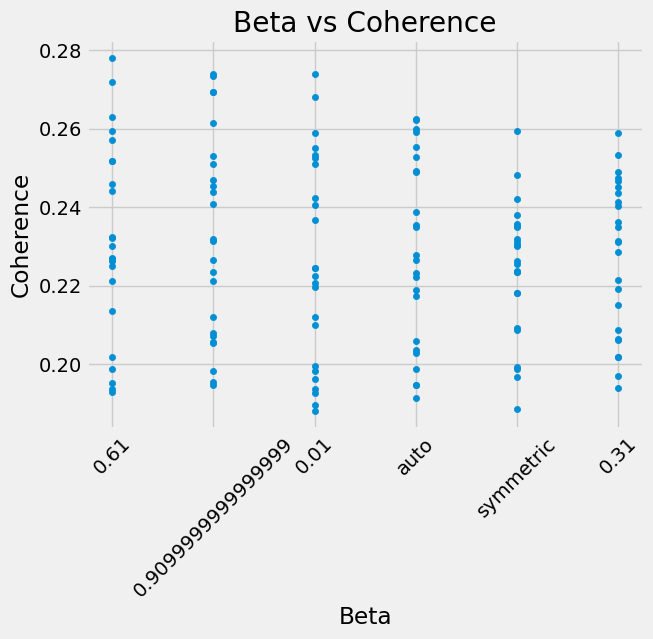

In [6]:
df_plot, best = tune_lda(TYPOLOGY, OUTPUT_DIR, RANDOM_STATE, CHUNKSIZE, PASSES, WORKERS, corpus, id2word, data_lemmatized, TYPOLOGY_TYPE=None)
plot_lda_tuning_result(df_plot)

In [23]:
lda_model_tuned, vis = lda_tuned_model(RANDOM_STATE, CHUNKSIZE, PASSES, WORKERS, corpus, id2word, best)
vis

2025-10-27 16:56:40,350 - WARNING - Failed to convert best_alpha to float. Using original value.
2025-10-27 16:56:40,354 - DEBUG - Training LDA model with tuned hyperparameters
2025-10-27 16:56:42,350 - DEBUG - Extracting top keywords per topic
2025-10-27 16:56:42,352 - INFO - Topic 0: wall, structure, durability, material, area, frame, surface, ability, concrete, characteristic
2025-10-27 16:56:42,352 - INFO - Topic 1: column, structure, element, material, facade, wall, concrete, beam, design, frame
2025-10-27 16:56:42,353 - INFO - Topic 2: material, brick, durability, wall, structure, environmental_factor, affordability, region, environmental_condition, masonry
2025-10-27 16:56:42,353 - INFO - Topic 3: metal, material, structure, steel, wall, use, sheet, wood, roofing, area
2025-10-27 16:56:42,353 - DEBUG - Performing inference on the corpus
2025-10-27 16:56:42,354 - DEBUG - Saving model to ./output/3_2/prompt_optlda_construction.model
2025-10-27 16:56:42,354 - DEBUG - {'uri': './out

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.095273 -0.036822       1        1  49.612194
1      0.157937 -0.046326       2        1  21.911640
2     -0.193246 -0.118626       3        1  16.344408
3     -0.059964  0.201774       4        1  12.131759, topic_info=           Term          Freq         Total Category  logprob  loglift
133       brick   5260.000000   5260.000000  Default  30.0000  30.0000
16        metal   3459.000000   3459.000000  Default  29.0000  29.0000
26     material  11824.000000  11824.000000  Default  28.0000  28.0000
25       column   4317.000000   4317.000000  Default  27.0000  27.0000
43       facade   2704.000000   2704.000000  Default  26.0000  26.0000
..          ...           ...           ...      ...      ...      ...
55      element    414.220759   4808.189309   Topic4  -3.8661  -0.3423
51        style    186.909886   1485.064991   Topic4  -4.6619   0.0368
13   durability    232.292314   7232.851393   Topic4  -4.4445  -1.3290
15        frame    159.156196   4388.745643   Topic4  -4.8226  -1.2076
1      concrete    148.460400   4505.214559   Topic4  -4.8922  -1.3033

[273 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
57        1  0.927418    ability
57        2  0.056457    ability
57        3  0.013206    ability
57        4  0.003302    ability
244       1  0.929922    ac_unit
...     ...       ...        ...
358       4  0.001694  withstand
340       1  0.040634       wood
340       2  0.013061       wood
340       3  0.017414       wood
340       4  0.928768       wood

[780 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4])

In [29]:
get_top_10_frequency_and_probability(lda_model_tuned)

2025-10-27 17:00:40,315 - DEBUG - Creating directories for plots: output/3_2/prompt_opt/plots_top_10_word_freq and output/3_2/prompt_opt/plots_top_10_word_prob
2025-10-27 17:00:40,319 - DEBUG - Computing weighted word frequencies per topic
2025-10-27 17:00:44,624 - DEBUG - Saving construction - Topic 0 - Top Word Frequencies plot at output/3_2/prompt_opt/plots_top_10_word_freq/construction_0.png
2025-10-27 17:00:44,848 - DEBUG - Saving construction - Topic 1 - Top Word Frequencies plot at output/3_2/prompt_opt/plots_top_10_word_freq/construction_1.png
2025-10-27 17:00:45,065 - DEBUG - Saving construction - Topic 2 - Top Word Frequencies plot at output/3_2/prompt_opt/plots_top_10_word_freq/construction_2.png
2025-10-27 17:00:45,286 - DEBUG - Saving construction - Topic 3 - Top Word Frequencies plot at output/3_2/prompt_opt/plots_top_10_word_freq/construction_3.png
2025-10-27 17:00:45,505 - DEBUG - Saving construction - Topic 0 - Word Probabilities plot at output/3_2/prompt_opt/plots_top